In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Data Exploration: Understanding the Raw Measurements

Before we attempt to mathematically "de-embed" our Device Under Test (DUT) from the test fixtures, we need to understand what our raw data looks like. In RF engineering, measurements are taken using a Vector Network Analyzer (VNA), which outputs **Scattering Parameters (S-parameters)**. 

For a 2-port network, we have four main S-parameters:
* **$S_{11}$ & $S_{22}$ (Reflection):** How much signal bounces back from the input/output.
* **$S_{21}$ & $S_{12}$ (Transmission):** How much signal successfully travels through the device.

Let's load our raw data in to a pandas dataframe, and load the frequencies column for plotting.

In [2]:
df = pd.read_csv("../measurement_data/dut_plus_fixture.csv")
frequencies = df["frequency_Hz"].values

# Reflection and Return Loss ($S_{11}$ & $S_{22}$)

**Return Loss ($RL$)** measures the power reflected back toward the source due to impedance mismatches in a transmission line. It is a critical indicator of how well the system impedance (usually $50\,\Omega$) matches the device under test.

* **$S_{11}$** represents the reflection coefficient at **Port 1**.
* **$S_{22}$** represents the reflection coefficient at **Port 2**.

In RF engineering, the reflection coefficient ($\Gamma$) is defined as the ratio of the reflected voltage wave to the incident voltage wave:

\begin{equation}
S_{11} = \frac{V_{reflected}}{V_{incident}}
\end{equation}

#### Magnitude of $S_{11}$

Given the complex components from the dataset ($S_{11} = \text{Re} + j\text{Im}$), the magnitude $|S_{11}|$ is calculated using the Pythagorean identity:

\begin{equation}
|S_{11}| = \sqrt{S_{11,real}^2 + S_{11,imag}^2}
\end{equation}

#### Conversion to Decibels (dB)

Return Loss is typically expressed in decibels. In this context, we calculate the log-magnitude of the reflection:

\begin{equation}
S_{11}(\text{dB}) = 20 \log_{10}(|S_{11}|)
\end{equation}

### Port Symmetry and Fixture Verification

Since our test setup and fixtures (PADs) are physically symmetric, the reflections measured at both ports should be virtually identical:

\begin{equation}
S_{11} \approx S_{22}
\end{equation}

Comparing these two traces allows us to verify the electrical symmetry of the setup. Any significant divergence would suggest a physical issue, such as a damaged cable, an imperfect connector contact, or an asymmetrical parasitic effect in one of the fixtures.

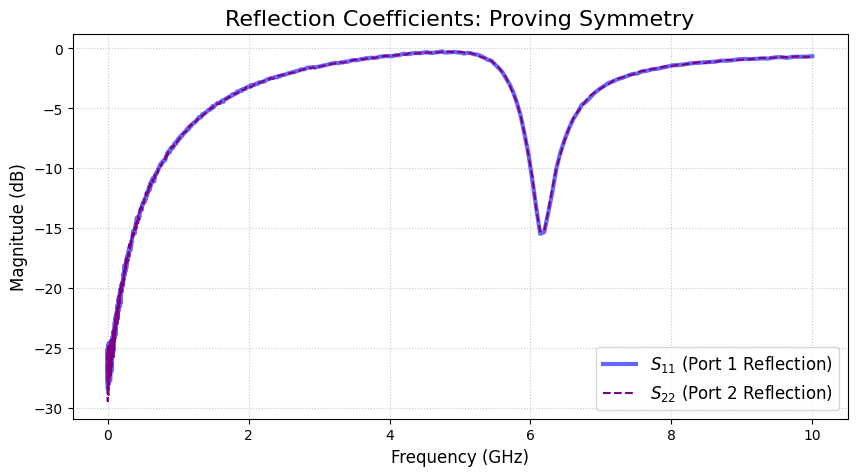

In [3]:
# Calculate S11
s11_mag = np.sqrt(df["S11_real"]**2 + df["S11_imag"]**2)
s11_db = 20 * np.log10(s11_mag + 1e-12)

# Calculate S22
s22_mag = np.sqrt(df["S22_real"]**2 + df["S22_imag"]**2)
s22_db = 20 * np.log10(s22_mag + 1e-12)

plt.figure(figsize=(10, 5))
plt.plot(frequencies / 1e9, s11_db, label="$S_{11}$ (Port 1 Reflection)", color="blue", linewidth=3, alpha=0.6)
plt.plot(frequencies / 1e9, s22_db, label="$S_{22}$ (Port 2 Reflection)", color="purple", linewidth=1.5, linestyle='--')

plt.title("Reflection Coefficients: Proving Symmetry", fontsize=16)
plt.xlabel("Frequency (GHz)", fontsize=12)
plt.ylabel("Magnitude (dB)", fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

## 2. Transmission / Insertion Loss ($S_{21}$ & $S_{12}$)

Transmission coefficients measure how much signal successfully travels through the device.
* **$S_{21}$ (Forward):** Signal injected at Port 1, measured at Port 2.
* **$S_{12}$ (Reverse):** Signal injected at Port 2, measured at Port 1.

Because passive components do not amplify signals and do not have directional dependencies, they are **reciprocal**. This means $S_{21}$ must equal $S_{12}$. Let's plot them to confirm our setup is reciprocal.

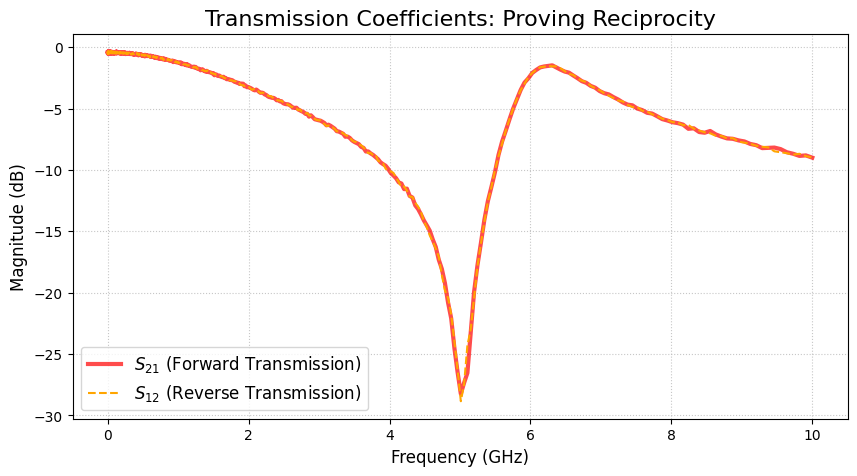

In [8]:
# Calculate S21
s21_mag = np.sqrt(df["S21_real"]**2 + df["S21_imag"]**2)
s21_db = 20 * np.log10(s21_mag + 1e-12)

# Calculate S12
s12_mag = np.sqrt(df["S12_real"]**2 + df["S12_imag"]**2)
s12_db = 20 * np.log10(s12_mag + 1e-12)

plt.figure(figsize=(10, 5))
plt.plot(frequencies / 1e9, s21_db, label="$S_{21}$ (Forward Transmission)", color="red", linewidth=3, alpha=0.7)
plt.plot(frequencies / 1e9, s12_db, label="$S_{12}$ (Reverse Transmission)", color="orange", linewidth=1.5, linestyle='--')

plt.title("Transmission Coefficients: Proving Reciprocity", fontsize=16)
plt.xlabel("Frequency (GHz)", fontsize=12)
plt.ylabel("Magnitude (dB)", fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

## Impact of Measurement Fixtures on RF Transmission

The plot below compares the **ideal transmission response of the DUT** with the **raw measurement obtained through fixtures**.  
The transmission parameter being analyzed is **S₂₁**, which describes how much of the input signal at Port 1 is transmitted to Port 2.

In RF systems:

- **|S₂₁| ≈ 1 (0 dB)** means nearly all power is transmitted.
- **|S₂₁| < 1 (negative dB)** indicates losses in the system.

The green curve represents the **Golden DUT response**, which corresponds to the intrinsic behavior of the device without any measurement artifacts.

The red curve represents the **raw measurement**, which includes:

- fixture parasitics
- impedance mismatch
- measurement noise

Several important effects can be observed in the current setup:

1. **Passband Transmission & Fixture Offset**
    Away from resonance, the ideal DUT allows full transmission (0 dB). The raw measurement (red curve) stays several dB below this, representing the **broadband loss and mismatch** from the PADs.

2. **Fixture-Induced Notch Distortion**
    The resonant notch at 5.03 GHz is clearly visible, but in the raw data, it is **shallower and broader**. The fixture parasitics "mask" the true rejection depth of the intrinsic RLC branch.

3. **High-Frequency Parasitic Roll-off**
    While the ideal DUT recovers to 0 dB after resonance, the raw measurement shows a continuous downward tilt. This is caused by the **shunt parasitic capacitance** of the fixtures draining the signal to ground at higher frequencies.

4. **Noise Floor Collision**
    At frequencies above 9 GHz, the raw signal becomes so weak that it hits the **measurement noise floor**. This is visible as jagged, random artifacts where the signal is no longer distinguishable from system noise.

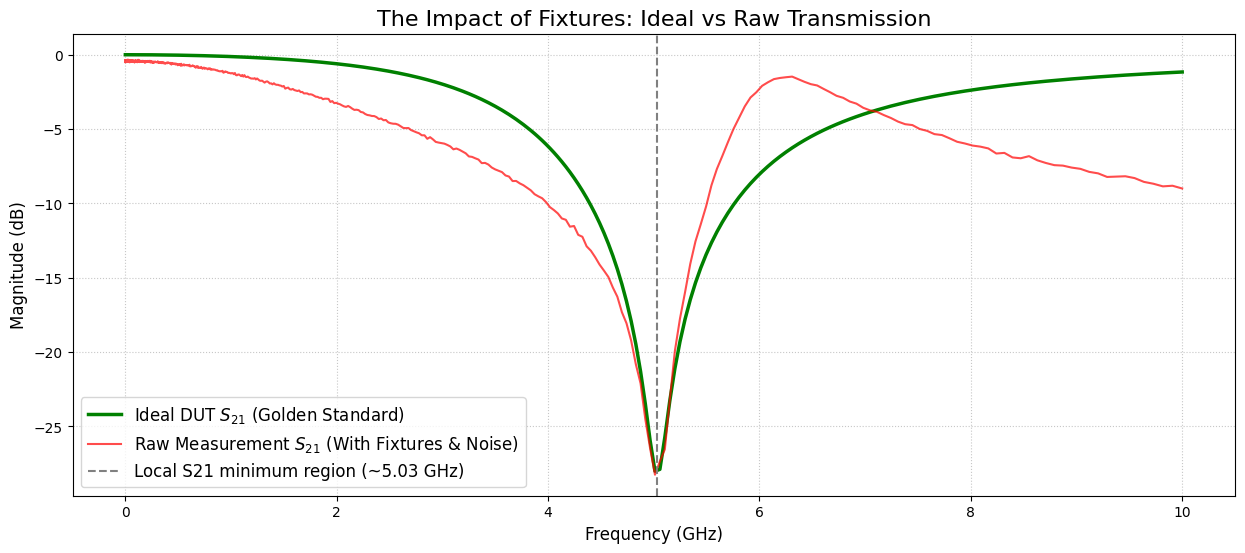

In [5]:
# Load the ideal data for comparison
df_golden = pd.read_csv("../measurement_data/golden_dut.csv")

# Calculate Golden S21 in dB
s21_gold_mag = np.sqrt(df_golden["S21_real"]**2 + df_golden["S21_imag"]**2)
s21_gold_db = 20 * np.log10(s21_gold_mag + 1e-12)

plt.figure(figsize=(15, 6))
plt.plot(frequencies / 1e9, s21_gold_db, label="Ideal DUT $S_{21}$ (Golden Standard)", color="green", linewidth=2.5)
plt.plot(frequencies / 1e9, s21_db, label="Raw Measurement $S_{21}$ (With Fixtures & Noise)", color="red", alpha=0.7)

plt.title("The Impact of Fixtures: Ideal vs Raw Transmission", fontsize=16)
plt.xlabel("Frequency (GHz)", fontsize=12)
plt.ylabel("Magnitude (dB)", fontsize=12)

plt.axvline(x=5.03, color='gray', linestyle='--', label='Local S21 minimum region (~5.03 GHz)')

plt.legend(fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

# Summary of Measured System Characteristics (Shunt Topology)

The system characteristics and electrical parameters detailed below are explicitly defined within the `rf_measurement_generator.py` script, which serves as the core synthetic data engine for this experiment.

---

## 1. Fundamental Network Properties

* **Passivity & Reciprocity:** The perfect overlap of $S_{21}$ and $S_{12}$ confirms that the system is a **passive reciprocal network**. No active gain is present, and signal transmission is identical in both directions.
* **Port Symmetry:** The alignment of $S_{11}$ and $S_{22}$ verifies that the input and output fixtures (PADs) are **identical (port-symmetric)**.

---

## 2. Device Under Test (DUT): The Notch Filter

### Topology & Synthesis Parameters

The DUT is implemented as a **shunt-connected series RLC branch** with the following synthesized values:

| Component | Symbol | Value | Description |
| --- | --- | --- | --- |
| **Resistance** | $R_{dut}$ | $1.0\ \Omega$ | Residual resistance at resonance. |
| **Inductance** | $L_{dut}$ | $1\text{ nH}$ | Series inductance of the branch. |
| **Capacitance** | $C_{dut}$ | $1\text{ pF}$ | Series capacitance of the branch. |

### Theoretical Resonance

Based on these parameters, the intrinsic resonance frequency is calculated as:

\begin{equation}
f_0 = \frac{1}{2\pi\sqrt{L \cdot C}} \approx 5.03 \text{ GHz}
\end{equation}

### Physical Behavior

At **5.03 GHz**, the impedance of the shunt branch drops to its minimum ($Z \approx 1\ \Omega$). Because it is connected in parallel to ground, it acts as an **RF Short**, creating the observed **Transmission Null (Notch)**.

---

## 3. Impact of Fixtures (PADs)

The measurement environment includes fixture pads that distort the ideal response of the DUT:

* **Fixture Configuration:** Each PAD is modeled as a shunt RC element with $R = 1000\ \Omega$ and $C = 1\text{ pF}$.
* **Parasitic Loading:** These pads act as low-pass filters. At higher frequencies, the $1\text{ pF}$ parasitic capacitance increasingly shorts the signal to ground, causing the observed downward tilt (roll-off) in the raw data.
* **Response Masking:** The fixtures reduce the depth of the notch and introduce impedance mismatches that shift the "raw" resonant peak compared to the "golden" standard.

---

## 4. Measurement Conditions

* **Points:** 1001 frequency points from 1 MHz to 10 GHz.
* **Noise Level:** A synthetic Gaussian noise floor of **0.0035** has been injected to simulate real-world VNA measurement uncertainty.

---

***This analysis confirms that the "Raw" signal is a combination of the 5.03 GHz notch and the frequency-dependent losses of the fixtures. The next step is to apply the De-embedding algorithm to mathematically strip away these PADs.***

---
